In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load 

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/gloriaalo/flipkart-product-reviews-with-sentiment-dataset/Dataset-SA.csv


**Import all Libraries needed**

In [3]:
#Import Libraries 

import pandas as pd
import numpy as np
from plotnine import *
import matplotlib.pyplot as plt
import seaborn as sns
import re, nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from collections import Counter
from wordcloud import WordCloud
from nltk import PorterStemmer, WordNetLemmatizer
from nltk import sent_tokenize
from nltk.tokenize import word_tokenize
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [4]:
# Download required NLTK data

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


**Load the Dataset**

In [5]:
#Load dataset

df = pd.read_csv('/kaggle/input/datasets/gloriaalo/flipkart-product-reviews-with-sentiment-dataset/Dataset-SA.csv')
df.head()

,product_name,product_price,Rate,Review,Summary,Sentiment
0,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,super!,great cooler excellent air flow and for this p...,positive
1,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,awesome,best budget 2 fit cooler nice cooling,positive
2,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3,fair,the quality is good but the power of air is de...,positive
3,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,1,useless product,very bad product its a only a fan,negative
4,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3,fair,ok ok product,neutral


**Explore the Dataset**

In [6]:
#Inspect dataset

print(df.shape)
print('_______________________________________________________________________')
print(df.columns.tolist)
print('_______________________________________________________________________')
print(df.info())
print('_______________________________________________________________________')
print(df['Sentiment'].value_counts())

(205052, 6)
_______________________________________________________________________
<bound method IndexOpsMixin.tolist of Index(['product_name', 'product_price', 'Rate', 'Review', 'Summary',
       'Sentiment'],
      dtype='object')>
_______________________________________________________________________
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205052 entries, 0 to 205051
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   product_name   205052 non-null  object
 1   product_price  205052 non-null  object
 2   Rate           205052 non-null  object
 3   Review         180388 non-null  object
 4   Summary        205041 non-null  object
 5   Sentiment      205052 non-null  object
dtypes: object(6)
memory usage: 9.4+ MB
None
_______________________________________________________________________
Sentiment
positive    166581
negative     28232
neutral      10239
Name: count, dtype: int64


**Clean the Dataset**

In [7]:
#Check for missing values

print('\nMissing values in Dataset\n')
print(df.isnull().sum())


Missing values in Dataset

product_name         0
product_price        0
Rate                 0
Review           24664
Summary             11
Sentiment            0
dtype: int64


In [8]:
#Work on missing values in dataset

# Fill Review with 'No review'
df['Review'] = df['Review'].fillna('No review')
print('Review cleaned\n')
print(df['Review'])

print('________________________________________________________________')

# Fill Summary with 'No summary'
df['Summary'] = df['Summary'].fillna('No summary')
print('\nSummary cleaned\n')
print(df['Summary'])

Review cleaned

0                  super!
1                 awesome
2                    fair
3         useless product
4                    fair
               ...       
205047          must buy!
205048             super!
205049               nice
205050          just wow!
205051    value-for-money
Name: Review, Length: 205052, dtype: object
________________________________________________________________

Summary cleaned

0         great cooler excellent air flow and for this p...
1                     best budget 2 fit cooler nice cooling
2         the quality is good but the power of air is de...
3                         very bad product its a only a fan
4                                             ok ok product
                                ...                        
205047                                         good product
205048                                                 nice
205049                          very nice and fast delivery
205050                         

In [9]:
#Check for duplicate rows

print('Dataset duplicate rows\n')
print(df.duplicated().sum())

Dataset duplicate rows

34375


In [10]:
#Remove duplicates, keep first occurence

df = df.drop_duplicates(keep="first")
print(df)

                                             product_name product_price Rate  \
0       Candes 12 L Room/Personal Air Cooler??????(Whi...          3999    5   
1       Candes 12 L Room/Personal Air Cooler??????(Whi...          3999    5   
2       Candes 12 L Room/Personal Air Cooler??????(Whi...          3999    3   
3       Candes 12 L Room/Personal Air Cooler??????(Whi...          3999    1   
4       Candes 12 L Room/Personal Air Cooler??????(Whi...          3999    3   
...                                                   ...           ...  ...   
205045  cello Pack of 18 Opalware Cello Dazzle Lush Fi...          1299    5   
205046  cello Pack of 18 Opalware Cello Dazzle Lush Fi...          1299    5   
205049  cello Pack of 18 Opalware Cello Dazzle Lush Fi...          1299    3   
205050  cello Pack of 18 Opalware Cello Dazzle Lush Fi...          1299    5   
205051  cello Pack of 18 Opalware Cello Dazzle Lush Fi...          1299    4   

                 Review                

In [11]:
#Check data types 

print(df.dtypes)

product_name     object
product_price    object
Rate             object
Review           object
Summary          object
Sentiment        object
dtype: object


In [12]:
#Convert data types

#Convert Rate to integer
df['Rate'] = pd.to_numeric(df['Rate'], errors='coerce')        #Convert to number
df['Rate'] = df['Rate'].astype('Int64') 
print(df['Rate'])

0         5
1         5
2         3
3         1
4         3
         ..
205045    5
205046    5
205049    3
205050    5
205051    4
Name: Rate, Length: 170677, dtype: Int64


**#Recheck dataset after cleaning**

In [13]:
#Check missing values after cleaning

print('\nMissing values after filling:\n')
print(df.isnull().sum())


Missing values after filling:

product_name     0
product_price    0
Rate             3
Review           0
Summary          0
Sentiment        0
dtype: int64


In [14]:
#Fill missing value in Rate with mean

mean_rate = round(df['Rate'].mean())
df['Rate'] = df['Rate'].fillna(mean_rate)
print(df['Rate'])

0         5
1         5
2         3
3         1
4         3
         ..
205045    5
205046    5
205049    3
205050    5
205051    4
Name: Rate, Length: 170677, dtype: Int64


In [15]:
#Check missing values after cleaning

print('\nMissing values after filling:\n')
print(df.isnull().sum())


Missing values after filling:

product_name     0
product_price    0
Rate             0
Review           0
Summary          0
Sentiment        0
dtype: int64


In [16]:
#Check for duplicates rows after cleaning
print(df.duplicated().sum())

0


In [17]:
#Check data types after cleaning
print(df.dtypes)

product_name     object
product_price    object
Rate              Int64
Review           object
Summary          object
Sentiment        object
dtype: object


In [18]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 170677 entries, 0 to 205051
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   product_name   170677 non-null  object
 1   product_price  170677 non-null  object
 2   Rate           170677 non-null  Int64 
 3   Review         170677 non-null  object
 4   Summary        170677 non-null  object
 5   Sentiment      170677 non-null  object
dtypes: Int64(1), object(5)
memory usage: 9.3+ MB
None


**Sentiment Distribution**

In [19]:
print(df.head(5)[['Rate','Review', 'Summary', 'Sentiment']])

   Rate           Review                                            Summary  \
0     5           super!  great cooler excellent air flow and for this p...   
1     5          awesome              best budget 2 fit cooler nice cooling   
2     3             fair  the quality is good but the power of air is de...   
3     1  useless product                  very bad product its a only a fan   
4     3             fair                                      ok ok product   

  Sentiment  
0  positive  
1  positive  
2  positive  
3  negative  
4   neutral  


In [20]:
#Combine Review and Summary Columns 

df['cleaned_text']=df['Review']+' '+ df['Summary']
df.head()

,product_name,product_price,Rate,Review,Summary,Sentiment,cleaned_text
0,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,super!,great cooler excellent air flow and for this p...,positive,super! great cooler excellent air flow and for...
1,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,awesome,best budget 2 fit cooler nice cooling,positive,awesome best budget 2 fit cooler nice cooling
2,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3,fair,the quality is good but the power of air is de...,positive,fair the quality is good but the power of air ...
3,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,1,useless product,very bad product its a only a fan,negative,useless product very bad product its a only a fan
4,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3,fair,ok ok product,neutral,fair ok ok product


In [21]:
# Sample cleaned_text per class

for sent in ['positive','negative','neutral']:
    sample = df[df.Sentiment==sent]['cleaned_text'].iloc[0]
    print(f"\n{sent.upper()}:\n{sample}")



POSITIVE:
super! great cooler excellent air flow and for this price its so amazing and unbelievablejust love it

NEGATIVE:
useless product very bad product its a only a fan

NEUTRAL:
fair ok ok product


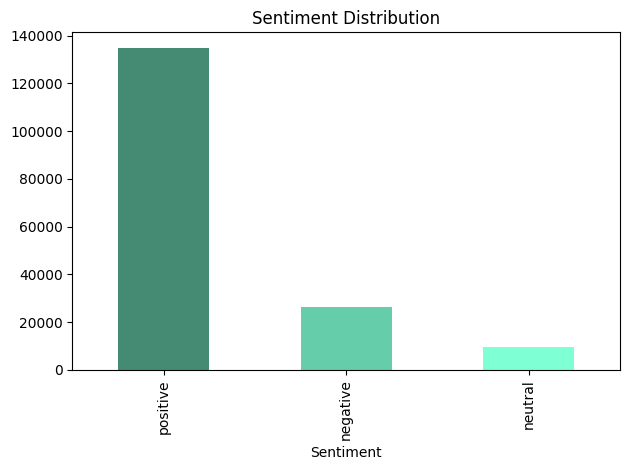

In [22]:
#Distribution plot

df['Sentiment'].value_counts().plot(
    kind= 'bar', color=['#458b74', '#66cdaa', '#7fffd4'])
plt.title('Sentiment Distribution')
plt.tight_layout()
plt.show()

**Text Preprocessing**

In [23]:
#preprocessing

def preprocess(text):
    text   = text.lower()
    text   = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(t)
              for t in tokens
              if t not in stop_words
              and len(t) > 2]
    return ' '.join(tokens)


# Apply to whole dataset
df['cleaned_text'] = df['Summary'].apply(preprocess)
print(df[['Summary','cleaned_text']].head(5))

                                             Summary  \
0  great cooler excellent air flow and for this p...   
1              best budget 2 fit cooler nice cooling   
2  the quality is good but the power of air is de...   
3                  very bad product its a only a fan   
4                                      ok ok product   

                                        cleaned_text  
0  great cooler excellent air flow price amazing ...  
1                best budget fit cooler nice cooling  
2                      quality good power air decent  
3                                    bad product fan  
4                                            product  


**Word Frequency Analysis**

In [24]:
# Join all clean text per sentiment
pos_words = ' '.join(df[df.Sentiment == 'positive']['cleaned_text'])
neg_words = ' '.join(df[df.Sentiment == 'negative']['cleaned_text'])
neu_words = ' '.join(df[df.Sentiment == 'neutral']['cleaned_text'])

# Print first 5 lines for each
print('=== Positive Words ===')
print(' '.join(pos_words.split()[:50]))   
print("\n")

print('=== Negative Words ===')
print(' '.join(neg_words.split()[:50]))
print("\n")

print('=== Neutral Words ===')
print(' '.join(neu_words.split()[:50]))

=== Positive Words ===
great cooler excellent air flow price amazing unbelievablejust love best budget fit cooler nice cooling quality good power air decent cooler really fantastic provides good air flow highly recommended good product nice good beautiful product good material perfectly working awesome good wonderful product must buy nice air cooler smart cool


=== Negative Words ===
bad product fan bad cooler bad quality small wire moter capacity low fan speed good flow vent hole lower part cooler difficult change water received dalay day cooler reveived switch damaged cooler provide cool air year experience quality product wood wool started falling next day two led indicator found working


=== Neutral Words ===
product average production speed slow built quality mark overall avearge cooling late water come slowly much big size performance reduced month nice cooling nice product body isnt properly fit overall goodbut warranty card month ago cooler jabardast honeycomb pad size big gu

In [25]:
# Get top 10 words per class

top_pos = Counter(pos_words.split()).most_common(10)
top_neg = Counter(neg_words.split()).most_common(10)
top_neu = Counter(neu_words.split()).most_common(10)

print("TOP POSITIVE WORDS:", top_pos[:5])
print("TOP NEGATIVE WORDS:", top_neg[:5])
print("TOP NEUTRAL WORDS:", top_neu[:5])

TOP POSITIVE WORDS: [('good', 58389), ('product', 47115), ('nice', 29791), ('quality', 16355), ('best', 10247)]
TOP NEGATIVE WORDS: [('product', 8219), ('quality', 5925), ('bad', 5914), ('good', 4912), ('dont', 2922)]
TOP NEUTRAL WORDS: [('product', 1528), ('good', 1346), ('quality', 855), ('average', 620), ('small', 609)]


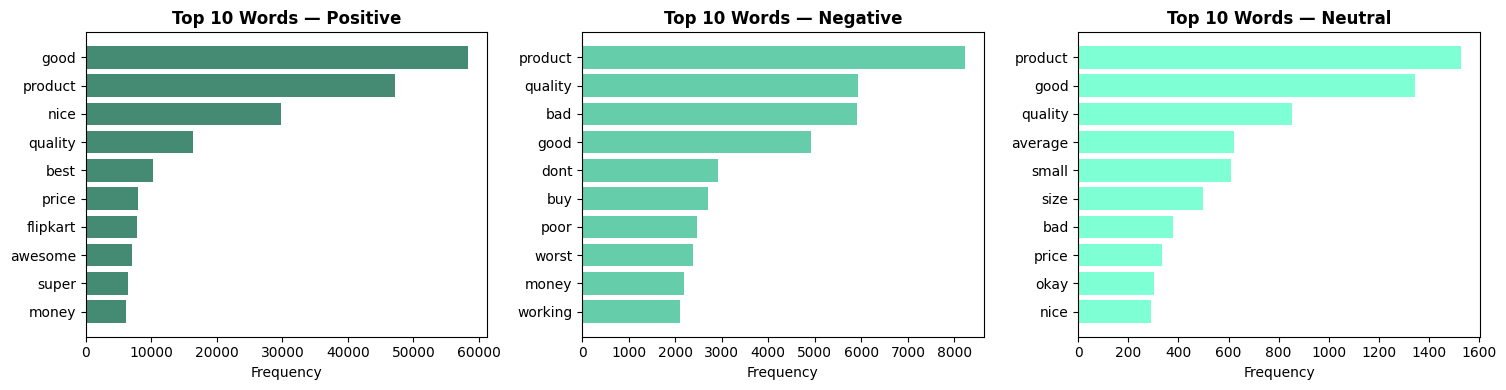

In [26]:
# Word Frequency per Sentiment 

# Plot for all three classes
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sentiments = ['positive', 'negative', 'neutral']
colors     = ['#458b74', '#66cdaa', '#7fffd4']

for ax, sent, color in zip(axes, sentiments, colors):
    
    # Join all cleaned text for this sentiment
    all_words = ' '.join(df[df.Sentiment==sent]['cleaned_text'])
    word_counts = Counter(all_words.split()).most_common(10)
    words, counts = zip(*word_counts)
    ax.barh(list(words)[::-1], list(counts)[::-1], color=color)
    ax.set_title(f'Top 10 Words — {sent.title()}', fontweight='bold')
    ax.set_xlabel('Frequency')

plt.tight_layout()
plt.show()


**Word Cloud Visualization**

#Generate word clouds for all three sentiment classes

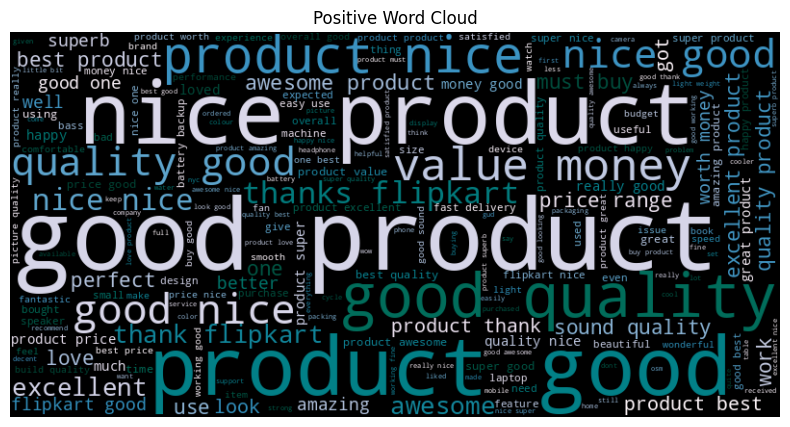

In [27]:
# Positive Word Cloud 

pos_text = ' '.join(df[df.Sentiment=='positive']['cleaned_text'])
wc = WordCloud(width=800, height=400,
               background_color='black',
               colormap='PuBuGn_r').generate(pos_text)
plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Positive Word Cloud')
plt.show()

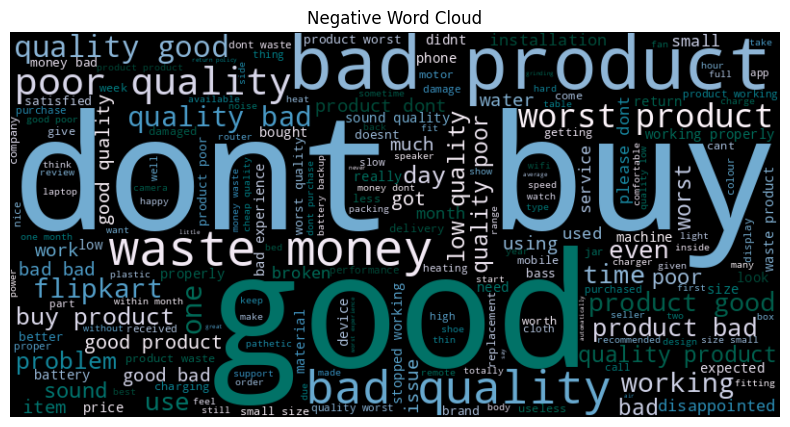

In [28]:
# Negative Word Cloud 

pos_text = ' '.join(df[df.Sentiment=='negative']['cleaned_text'])
wc = WordCloud(width=800, height=400,
               background_color='black',
               colormap='PuBuGn_r').generate(pos_text)
plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Negative Word Cloud')
plt.show()


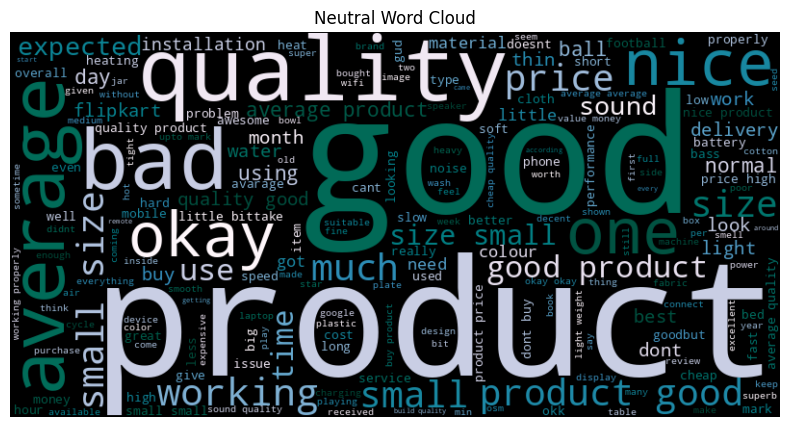

In [29]:
# Neutral Word Cloud 

pos_text = ' '.join(df[df.Sentiment=='neutral']['cleaned_text'])
wc = WordCloud(width=800, height=400,
               background_color='black',
               colormap='PuBuGn_r').generate(pos_text)
plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Neutral Word Cloud')
plt.show()

**Word Tokenization**

In [30]:
# Sample headline

text = 'Beautiful product good material and perfectly working.'

In [31]:
# Word tokenization 

word_tokens = word_tokenize(text)
print("Word tokens:", word_tokens)
print("Count:", len(word_tokens))

Word tokens: ['Beautiful', 'product', 'good', 'material', 'and', 'perfectly', 'working', '.']
Count: 8


In [32]:
# Sentence tokenization
sent_tokens = sent_tokenize(text)
print("\nSentence tokens:", sent_tokens)


Sentence tokens: ['Beautiful product good material and perfectly working.']


In [33]:
# Apply to dataset

sample = df['cleaned_text'].iloc[0]
tokens = word_tokenize(sample.lower())
print("\nSample tokens:", tokens)



Sample tokens: ['great', 'cooler', 'excellent', 'air', 'flow', 'price', 'amazing', 'unbelievablejust', 'love']


**Stemming vs Lemmatization in Code**

In [34]:
stemmer    = PorterStemmer()
lemmatizer = WordNetLemmatizer()

# Test words from headlines
test_words = [
    'beautiful', 'expected', 'excellent',
    'material', 'working', 'quality',
    'amazing', 'unbelievable', 'delivery'
]

print(f"{'Word':<15} {'Stemmed':<15} {'Lemmatized':<15}")
print("-" * 45)
for word in test_words:
    stemmed   = stemmer.stem(word)
    lemmatized = lemmatizer.lemmatize(word, pos='v')  # pos='v' for verbs
    print(f"{word:<15} {stemmed:<15} {lemmatized:<15}")

# Apply lemmatization to dataset
df['lemma_text'] = df['cleaned_text'].apply(
    lambda t: ' '.join([
        lemmatizer.lemmatize(w, pos='v') for w in t.split()
    ])
)

Word            Stemmed         Lemmatized     
---------------------------------------------
beautiful       beauti          beautiful      
expected        expect          expect         
excellent       excel           excellent      
material        materi          material       
working         work            work           
quality         qualiti         quality        
amazing         amaz            amaze          
unbelievable    unbeliev        unbelievable   
delivery        deliveri        delivery       


**Label Encoding**

In [35]:
le = LabelEncoder()
df['Label'] = le.fit_transform(df['Sentiment'])
print(df['Label'].head(5))

0    2
1    2
2    2
3    0
4    1
Name: Label, dtype: int64


**TF-IDF Vectorization**

In [36]:
# Prepare features (X) and labels (y)

X = df['cleaned_text']
y = df['Sentiment']           # 0=negative  1=positive  2=neutral

In [37]:
# Train-test split (80% / 20%, stratified)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,
    random_state = 42,
    stratify     = y
)

In [38]:
# Create and fit TF-IDF (ONLY fit on Train data)

tfidf = TfidfVectorizer(
    max_features = 500,       # top 500 words only
    ngram_range  = (1, 2),   # unigrams and bigrams
    min_df       = 2          # ignore very rare words
)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)   # NO fit here!

print(f"Train matrix: {X_train_tfidf.shape}")
print(f"Test matrix:  {X_test_tfidf.shape}")


Train matrix: (136541, 500)
Test matrix:  (34136, 500)


**Train Logistic Regression & Evaluate**

In [39]:
# Train model

clf = LogisticRegression(
    max_iter     = 1000,
    C            = 1.0,      # regularisation (lower = simpler)
    random_state = 42
)
clf.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [40]:
rf_train = clf.score(X_train_tfidf, y_train)
rf_test  = clf.score(X_test_tfidf,  y_test)

print(f"LogisticRegression  Train:{rf_train:.2%}  Test:{rf_test:.2%}")

LogisticRegression  Train:88.51%  Test:88.50%


In [41]:
# Predict
y_pred = clf.predict(X_test_tfidf)

In [42]:
# Accuracy evaluation
acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {acc:.2%}")

# Classification report
print(classification_report(
    y_test, y_pred,
    target_names=['Negative','Positive','Neutral']
))


Test Accuracy: 88.50%
              precision    recall  f1-score   support

    Negative       0.81      0.66      0.73      5295
    Positive       0.66      0.17      0.27      1900
     Neutral       0.90      0.98      0.94     26941

    accuracy                           0.89     34136
   macro avg       0.79      0.61      0.65     34136
weighted avg       0.87      0.89      0.87     34136



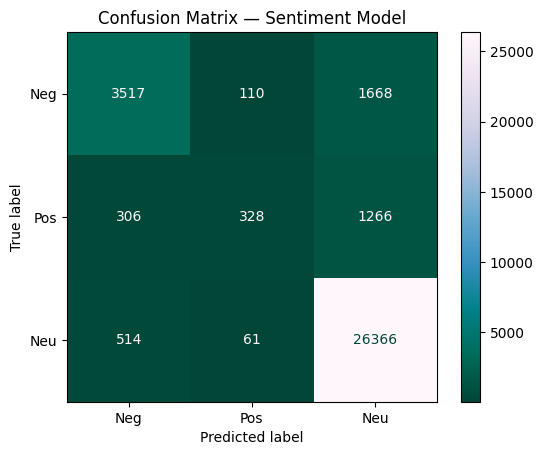

In [43]:
# Confusion matrix
cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm,
         display_labels=['Neg','Pos','Neu'])
disp.plot(cmap='PuBuGn_r')
plt.title("Confusion Matrix — Sentiment Model")
plt.show()


**Model Comparison with Random Forest**

In [44]:
#Train Model Using Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    max_features='sqrt',
    oob_score=True,
    max_depth=4,
    min_samples_split=5,
    class_weight="balanced",
    random_state=42, n_jobs=-1
)
rf.fit(X_train_tfidf, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=4,
                       min_samples_split=5, n_jobs=-1, oob_score=True,
                       random_state=42)

In [45]:
rf_train = rf.score(X_train_tfidf, y_train)
rf_test  = rf.score(X_test_tfidf,  y_test)

print(f"Random Forest  Train:{rf_train:.2%}  Test:{rf_test:.2%}")
print(f"Random Forest  OOB:  {rf.oob_score_:.2%}")

Random Forest  Train:72.11%  Test:72.27%
Random Forest  OOB:  71.14%


In [46]:
#Predict
y_pred=rf.predict(X_test_tfidf)

# Accuracy evaluation
acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {acc:.2%}")

#Classiication Report
for name, mdl in [("Random Forest",rf)]:
    print(f"\n--- {name} Report ---")
    print(classification_report(
        y_test, y_pred,
        target_names=['Negative','Positive','Neutral']))

Test Accuracy: 72.27%

--- Random Forest Report ---
              precision    recall  f1-score   support

    Negative       0.78      0.54      0.64      5295
    Positive       0.16      0.77      0.27      1900
     Neutral       0.95      0.76      0.84     26941

    accuracy                           0.72     34136
   macro avg       0.63      0.69      0.58     34136
weighted avg       0.88      0.72      0.78     34136



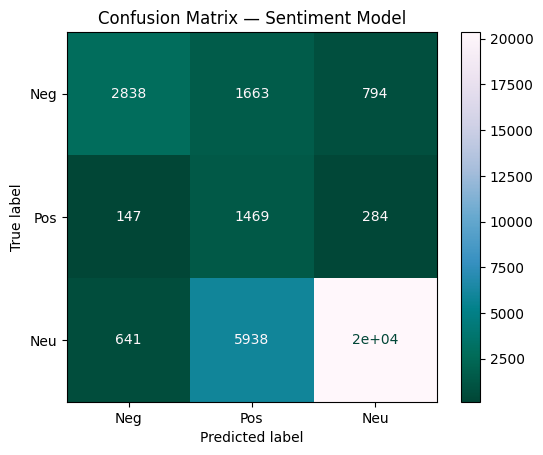

In [47]:
# Confusion matrix

cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm,
         display_labels=['Neg','Pos','Neu'])
disp.plot(cmap='PuBuGn_r')
plt.title("Confusion Matrix — Sentiment Model")
plt.show()

**CONCLUSION**

This project successfully performed Data Cleaning, Exploratory Data Analysis and built a simple Sentiment Analysis model on the Flipkart product reviews dataset. Using the pre-labeled sentiment column (positive, negative, neutral), I explored customer opinions across 104 different product categories and trained two distinct Machine Learning Models for comparison (Logistic Regression Model vs Random Forest Model) .

While comparing both Models, I discovered that, Logistic Regression Model outperforms Random Forest Model.

Logistic Regression Model achieved good performance in predicting sentiment from review summaries better than Random Forest Model.

Logistic Regression Model achieved better overall accuracy of 88.50% on the test data and was much faster to train,it performed especially well on the "positive" class. **WHILE** Random Forest Model showed slightly lower accuracy of 72.27% and took longer to train, though it can sometimes capture complex patterns better.

Both models struggled more with the **Neutral** class compared to Positive and Negative. (this is common because neutral reviews use subtler language).

Based on Model selection; the Logistic Regression model is the better choice for this dataset and it was selected for the final pipeline due to its computational efficiency,it is faster, simpler, and gives slightly better performance.

Overall, this Sentiment analysis shows that customer sentiment on Flipkart is mostly positive, but there is still room for improvement, especially in the neutral and negative segments.

